In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt


In [2]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [3]:
class SegmentationDataset(Dataset):
    def __init__(self, root, image_folder="images", mask_folder="masks", transforms=None):
        self.root = root
        self.transforms = transforms
        self.image_folder = os.path.join(root, image_folder)
        self.mask_folder = os.path.join(root, mask_folder)
        self.image_names = sorted(os.listdir(self.image_folder))
        self.mask_names = sorted(os.listdir(self.mask_folder))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_names[idx])
        mask_path = os.path.join(self.mask_folder, self.mask_names[idx])
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Grayscale mask
        if self.transforms:
            image = self.transforms(image)
            mask = transforms.ToTensor()(mask)  # Mask to tensor (0-1 range)
        return {"image": image, "mask": mask}

In [5]:
def create_deeplab(output_channels=1):
    model = models.segmentation.deeplabv3_resnet101(pretrained=True)
    model.classifier = DeepLabHead(2048, output_channels)
    return model

In [6]:
import os
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION'

In [7]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection'

In [8]:
from Solar_Rooftop_Detection.accuracy import compute_metrics

In [9]:
def train_model(model, dataloader, num_epochs=25):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = torch.nn.BCEWithLogitsLoss()  # For binary segmentation
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_list = []
    model.train()  # Set model to training mode

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        running_loss = 0.0
        for sample in tqdm(dataloader):
            inputs = sample["image"].to(device)
            masks = sample["mask"].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)["out"]  # Shape: (batch, 1, H, W)
            # print(outputs.shape)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        running_loss = running_loss / len(dataloader.dataset)
        loss_list.append(running_loss)
        print(f"Train Loss: {running_loss:.4f}")
        
    return model, loss_list

In [10]:
data_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/ROAD_DATASET/train"
transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
])

In [11]:
dataset = SegmentationDataset(data_dir, transforms=transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [12]:
dataset[0]

{'image': tensor([[[0.5333, 0.4431, 0.2745,  ..., 0.4824, 0.5098, 0.5020],
          [0.3765, 0.4196, 0.4431,  ..., 0.4902, 0.4980, 0.4902],
          [0.4196, 0.3490, 0.4314,  ..., 0.4980, 0.5098, 0.4980],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 0.0824, 0.0941, 0.1098],
          [1.0000, 1.0000, 1.0000,  ..., 0.0510, 0.1529, 0.1961],
          [1.0000, 1.0000, 1.0000,  ..., 0.0549, 0.1020, 0.0941]],
 
         [[0.4314, 0.3686, 0.2510,  ..., 0.4471, 0.4588, 0.4549],
          [0.3020, 0.3412, 0.3686,  ..., 0.4510, 0.4510, 0.4510],
          [0.3451, 0.3098, 0.3529,  ..., 0.4549, 0.4706, 0.4667],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 0.1333, 0.1333, 0.1373],
          [1.0000, 1.0000, 1.0000,  ..., 0.0980, 0.1765, 0.1961],
          [1.0000, 1.0000, 1.0000,  ..., 0.0902, 0.1451, 0.1451]],
 
         [[0.3529, 0.3137, 0.2392,  ..., 0.3569, 0.3608, 0.3608],
          [0.3098, 0.3137, 0.2941,  ..., 0.3529, 0.3490, 0.3608],
          [0.2706, 0.2667, 0.31

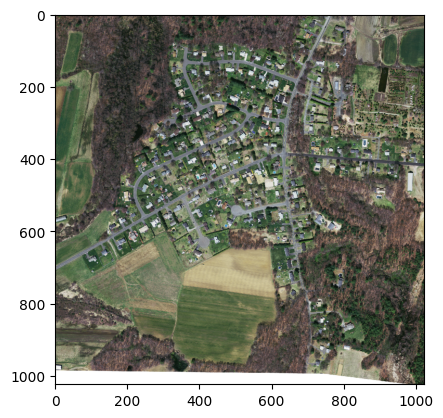

In [13]:
plt.imshow(dataset[0]["image"].permute(1, 2, 0))
plt.show()

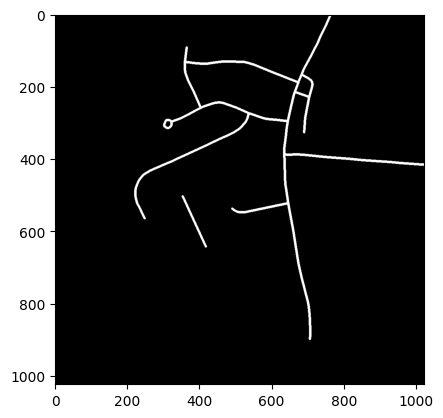

In [14]:
plt.imshow(dataset[0]["mask"].squeeze(), cmap="gray")
plt.show()

In [ ]:
model = create_deeplab(output_channels=1)
trained_model, losses = train_model(model, dataloader, num_epochs=50)

/home/dhruv/Documents/my_python_envs/solar_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dhruv/Documents/my_python_envs/solar_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50


  7%|▋         | 162/2216 [01:07<14:16,  2.40it/s]

In [ ]:
torch.save(trained_model, "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3/deeplab_rooftop_full_50.pth")
print("Training complete, entire model saved as 'deeplab_rooftop_full_50.pth'")

Training complete, entire model saved as 'deeplab_rooftop_full_50.pth'


In [ ]:
losses

[0.14079176277991398,
 0.11616561696814232,
 0.10483742409405913,
 0.1041449482934314,
 0.09695240578594003,
 0.10071319136650904,
 0.0988403732975817,
 0.10148717433765585,
 0.09905770465871151,
 0.09597423533902298,
 0.09740159883279864,
 0.09008406456484247,
 0.08820775635616135,
 0.08685316632305094,
 0.08496936768611106,
 0.08319978568966026,
 0.08129808503990683,
 0.08166620688048941,
 0.08717361687336266,
 0.0888958702755702,
 0.08648069715799785,
 0.08816592148479935,
 0.09091306087520605,
 0.08628818944024279,
 0.09039268132748035,
 0.08698560535573209,
 0.09122897990195868,
 0.087209734013758,
 0.08336915457469919,
 0.08003328773693184,
 0.07880693732778499,
 0.08065513861012588,
 0.07781893719283575,
 0.07729474721738686,
 0.07509844259708609,
 0.073368087932064,
 0.07180684700142592,
 0.08486841118344801,
 0.08295533078300703,
 0.08351783847666618,
 0.08263025046679248,
 0.07778931137835035,
 0.07632843448212269,
 0.07597247635696036,
 0.07554869632957846,
 0.07498064119493

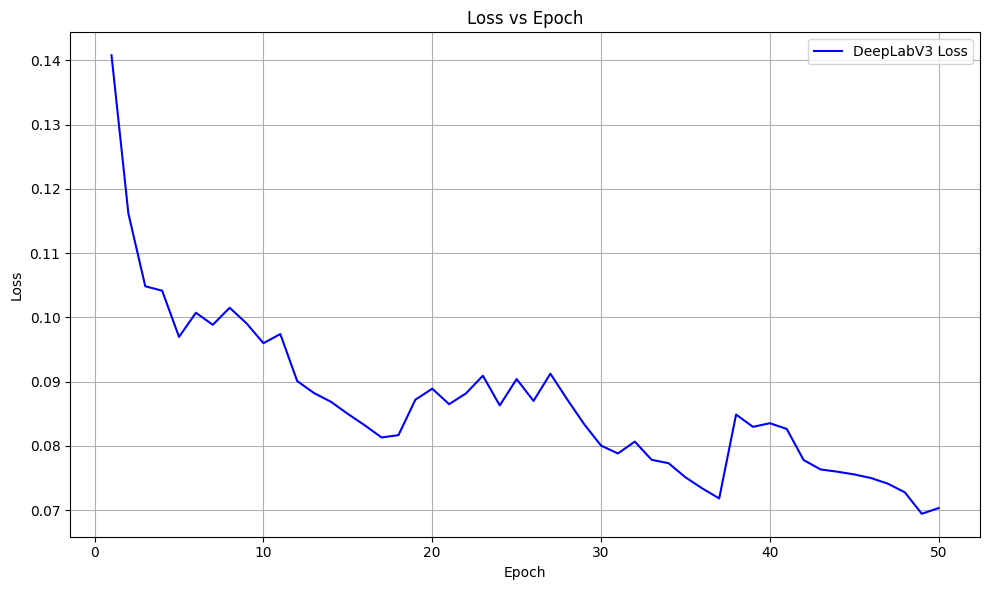

In [ ]:
import matplotlib.pyplot as plt


deeplabv3_loss = losses
epochs = list(range(1,51))

# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, deeplabv3_loss, label='DeepLabV3 Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3/deeplabv3_loss_vs_epochs.png")
plt.tight_layout()
plt.show()

In [ ]:
new_model = torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_ROAD_SEGMENTATION/results/deeplabv3/deeplab_rooftop_full_50.pth")
print("Model loaded successfully")